In [1]:
import pandas as pd

df = pd.read_csv("../data/NYC.csv")

df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


In [2]:
df.shape


(1458644, 11)

In [3]:
df.columns

Index(['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime',
       'passenger_count', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag',
       'trip_duration'],
      dtype='str')

In [4]:
df.dtypes


id                        str
vendor_id               int64
pickup_datetime           str
dropoff_datetime          str
passenger_count         int64
pickup_longitude      float64
pickup_latitude       float64
dropoff_longitude     float64
dropoff_latitude      float64
store_and_fwd_flag        str
trip_duration           int64
dtype: object

In [5]:
df.isnull().sum()

id                    0
vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.describe()

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
count,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06
mean,1.534950e+00,1.664530e+00,-7.397349e+01,4.075092e+01,-7.397342e+01,4.075180e+01,9.594923e+02
std,4.987772e-01,1.314242e+00,7.090186e-02,3.288119e-02,7.064327e-02,3.589056e-02,5.237432e+03
min,1.000000e+00,0.000000e+00,-1.219333e+02,3.435970e+01,-1.219333e+02,3.218114e+01,1.000000e+00
25%,1.000000e+00,1.000000e+00,-7.399187e+01,4.073735e+01,-7.399133e+01,4.073588e+01,3.970000e+02
50%,2.000000e+00,1.000000e+00,-7.398174e+01,4.075410e+01,-7.397975e+01,4.075452e+01,6.620000e+02
75%,2.000000e+00,2.000000e+00,-7.396733e+01,4.076836e+01,-7.396301e+01,4.076981e+01,1.075000e+03
max,2.000000e+00,9.000000e+00,-6.133553e+01,5.188108e+01,-6.133553e+01,4.392103e+01,3.526282e+06


In [8]:
df.nlargest(10, "trip_duration")[[
    "id",
    "pickup_datetime",
    "dropoff_datetime",
    "passenger_count",
    "pickup_longitude",
    "pickup_latitude",
    "dropoff_longitude",
    "dropoff_latitude",
    "trip_duration"
]]

,id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
978383,id0053347,2016-02-13 22:46:52,2016-03-25 18:18:14,1,-73.783905,40.648632,-73.978271,40.750202,3526282
924150,id1325766,2016-01-05 06:14:15,2016-01-31 01:01:07,1,-73.983788,40.742325,-73.985489,40.727676,2227612
680594,id0369307,2016-02-13 22:38:00,2016-03-08 15:57:38,2,-73.921677,40.735252,-73.984749,40.759979,2049578
355003,id1864733,2016-01-05 00:19:42,2016-01-27 11:08:38,1,-73.789650,40.643559,-73.956810,40.773087,1939736
1234291,id1942836,2016-02-15 23:18:06,2016-02-16 23:17:58,2,-73.794525,40.644825,-73.991051,40.755573,86392
295382,id0593332,2016-05-31 13:00:39,2016-06-01 13:00:30,1,-73.781952,40.644688,-73.993874,40.745926,86391
73816,id0953667,2016-05-06 00:00:10,2016-05-07 00:00:00,1,-73.996010,40.753220,-73.979027,40.740601,86390
59891,id2837671,2016-06-30 16:37:52,2016-07-01 16:37:39,1,-73.992279,40.749729,-73.962524,40.800770,86387
1360439,id1358458,2016-06-23 16:01:45,2016-06-24 16:01:30,1,-73.782089,40.644806,-73.985016,40.666828,86385
753765,id2589925,2016-05-17 22:22:56,2016-05-18 22:22:35,4,-74.006111,40.734680,-73.958809,40.815449,86379


In [9]:
row = df.loc[978383]

pickup = pd.to_datetime(row["pickup_datetime"])
dropoff = pd.to_datetime(row["dropoff_datetime"])

dropoff - pickup

Timedelta('40 days 19:31:22')

In [10]:
(dropoff - pickup).total_seconds()

3526282.0

In [11]:
(df["trip_duration"] > 86400).sum()

np.int64(4)

In [12]:
df[df["trip_duration"] > 86400][[
    "id",
    "pickup_datetime",
    "dropoff_datetime",
    "passenger_count",
    "pickup_longitude",
    "pickup_latitude",
    "dropoff_longitude",
    "dropoff_latitude",
    "trip_duration"
]]

,id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
355003,id1864733,2016-01-05 00:19:42,2016-01-27 11:08:38,1,-73.789650,40.643559,-73.956810,40.773087,1939736
680594,id0369307,2016-02-13 22:38:00,2016-03-08 15:57:38,2,-73.921677,40.735252,-73.984749,40.759979,2049578
924150,id1325766,2016-01-05 06:14:15,2016-01-31 01:01:07,1,-73.983788,40.742325,-73.985489,40.727676,2227612
978383,id0053347,2016-02-13 22:46:52,2016-03-25 18:18:14,1,-73.783905,40.648632,-73.978271,40.750202,3526282


In [13]:
df["trip_duration"].quantile([0.50, 0.75, 0.90, 0.95, 0.99, 0.999])

0.500      662.000
0.750     1075.000
0.900     1634.000
0.950     2104.000
0.990     3440.000
0.999    85128.357
Name: trip_duration, dtype: float64

In [14]:
df["trip_duration"].apply(
    lambda x: x / 3600
).describe(percentiles=[0.90, 0.95, 0.99, 0.999])

count    1.458644e+06
mean     2.665256e-01
std      1.454842e+00
min      2.777778e-04
90%      4.538889e-01
95%      5.844444e-01
99%      9.555556e-01
99.9%    2.364677e+01
max      9.795228e+02
Name: trip_duration, dtype: float64

In [15]:
df["passenger_count"].value_counts().sort_index()

passenger_count
0         60
1    1033540
2     210318
3      59896
4      28404
5      78088
6      48333
7          3
8          1
9          1
Name: count, dtype: int64

In [16]:
(df["passenger_count"] == 0).mean() * 100

np.float64(0.0041134094405488935)

In [17]:
df[
    (df["pickup_longitude"] < -75) |
    (df["pickup_longitude"] > -72)
].shape

(26, 11)

In [18]:
df[
    (df["pickup_longitude"] < -75) |
    (df["pickup_longitude"] > -72)
][[
    "id",
    "pickup_longitude",
    "pickup_latitude",
    "dropoff_longitude",
    "dropoff_latitude",
    "trip_duration"
]]

,id,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
114376,id1311087,-75.455917,39.803932,-73.796021,40.707726,23440
193116,id2769862,-77.896019,37.777771,-77.896019,37.777771,417
233451,id1703300,-77.039436,38.898849,-77.039436,38.898849,60
235449,id2298947,-77.039436,38.898849,-77.039436,38.898849,60
275644,id0978162,-75.354332,34.712234,-73.834923,32.181141,875
483718,id1245825,-70.851616,43.017578,-70.851616,43.017578,1486
521870,id2823997,-70.511902,42.458942,-70.511902,42.458942,224
595540,id1723416,-78.547401,40.817131,-79.786133,40.917637,279
646333,id2209294,-75.524620,39.441147,-75.524620,39.441147,174
656806,id2344725,-75.241493,41.430660,-75.570152,41.201477,684


In [19]:
df[
    (df["pickup_latitude"] < 40) |
    (df["pickup_latitude"] > 41)
].shape

(96, 11)

In [20]:
df[
    (df["pickup_latitude"] < 40) |
    (df["pickup_latitude"] > 41)
][[
    "id",
    "pickup_longitude",
    "pickup_latitude",
    "dropoff_longitude",
    "dropoff_latitude",
    "trip_duration"
]]

,id,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
31618,id2185383,-73.518051,41.091171,-73.518059,41.091167,42
47764,id1792628,-73.766754,41.032238,-73.766754,41.032238,31
55994,id0800130,-73.804291,41.002628,-73.804283,41.002548,29
66344,id0240882,-73.688805,41.006001,-74.005753,40.725510,5226
70185,id1718992,-73.773476,41.039185,-73.773476,41.039181,29
...,...,...,...,...,...,...
1387351,id0205460,-65.897385,39.457882,-65.897385,39.457882,329
1412011,id0895501,-73.370911,41.123074,-73.370911,41.123074,8
1416336,id3795134,-75.238327,39.923027,-73.922577,40.610130,17363
1421231,id2289034,-73.582321,41.026653,-73.582321,41.026653,6


In [21]:
df["pickup_datetime"].min(), df["pickup_datetime"].max()

('2016-01-01 00:00:17', '2016-06-30 23:59:39')

In [22]:
df["vendor_id"].value_counts()

vendor_id
2    780302
1    678342
Name: count, dtype: int64

In [23]:
df["store_and_fwd_flag"].value_counts()

store_and_fwd_flag
N    1450599
Y       8045
Name: count, dtype: int64

### Categorical Feature Summary

- `vendor_id` contains two vendors: 1 and 2.
- Vendor 2 has 780,302 trips, while Vendor 1 has 678,342 trips.
- `store_and_fwd_flag` contains two categories: N and Y.
- Most trips have `N` (1,450,599), while only 8,045 trips have `Y`.
- Both columns have no missing values.
- Both are categorical features and will be kept for further analysis and feature engineering.

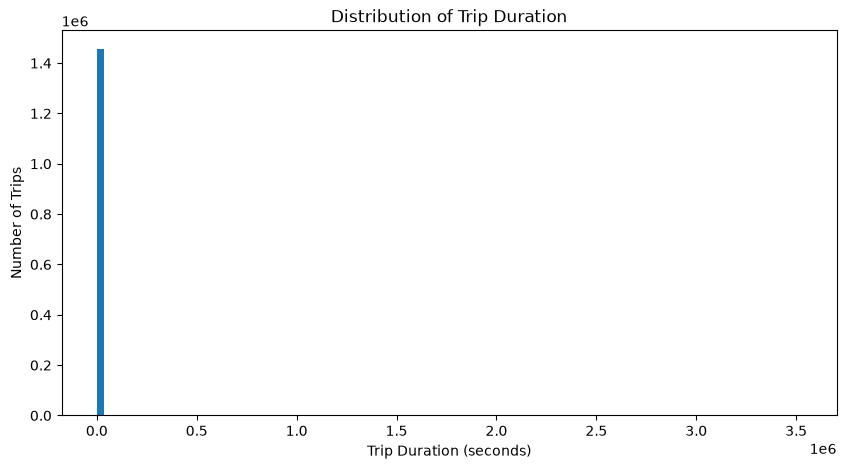

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(df["trip_duration"], bins=100)

plt.xlabel("Trip Duration (seconds)")
plt.ylabel("Number of Trips")
plt.title("Distribution of Trip Duration")

plt.show()

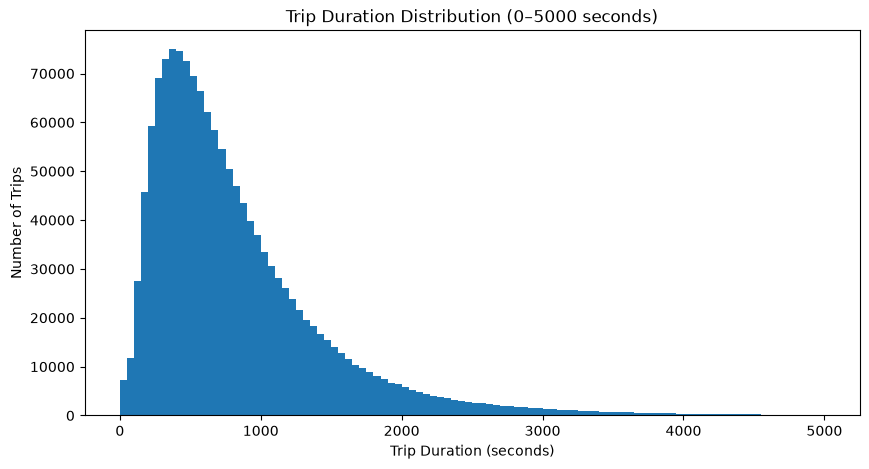

In [26]:
plt.figure(figsize=(10, 5))

plt.hist(df["trip_duration"], bins=100, range=(0, 5000))

plt.xlabel("Trip Duration (seconds)")
plt.ylabel("Number of Trips")
plt.title("Trip Duration Distribution (0–5000 seconds)")

plt.show()

In [27]:
df.groupby("passenger_count")["trip_duration"].mean()

passenger_count
0    1718.433333
1     930.399753
2    1005.458335
3    1028.236276
4    1053.529749
5    1070.232174
6    1061.355223
7      19.666667
8     104.000000
9     560.000000
Name: trip_duration, dtype: float64

### Passenger Count vs Trip Duration

- The average trip duration varies across passenger counts.
- For passenger counts 1–6, the average duration is roughly 15–18 minutes.
- Passenger counts 7, 8, and 9 have very few observations, so their averages are not reliable for general conclusions.
- Passenger count 0 also has very few observations and should be investigated separately.
- Passenger count may contain useful information for prediction, but the relationship with trip duration is not necessarily causal.

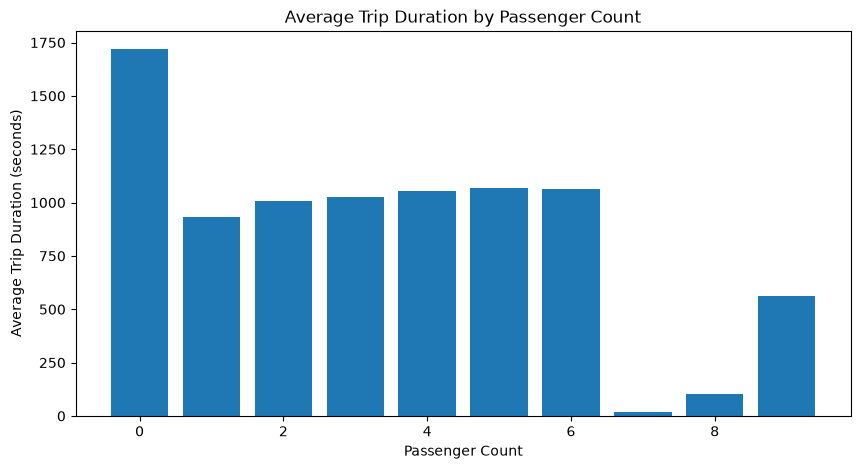

In [28]:
avg_duration_by_passengers = (
    df.groupby("passenger_count")["trip_duration"]
    .mean()
)

plt.figure(figsize=(10, 5))

plt.bar(
    avg_duration_by_passengers.index,
    avg_duration_by_passengers.values
)

plt.xlabel("Passenger Count")
plt.ylabel("Average Trip Duration (seconds)")
plt.title("Average Trip Duration by Passenger Count")

plt.show()

In [29]:
df[df["passenger_count"].isin([0, 7, 8, 9])][
    ["passenger_count", "trip_duration"]
]

,passenger_count,trip_duration
62744,0,85901
136519,0,4
194288,0,155
217765,0,2251
263809,0,8
...,...,...
1371117,0,6
1414111,0,48
1433427,0,981
1443353,0,35


### Passenger Count vs Trip Duration

- For passenger counts 1–6, average trip duration is roughly 15–18 minutes.
- Passenger count 0 has only 60 observations and contains highly variable trip durations, including an extreme value, so its average is strongly affected by unusual observations.
- Passenger counts 7, 8, and 9 have extremely few observations, so their averages are not reliable for general conclusions.
- Passenger count may still be useful as a predictive feature, but unusual and rare values should be investigated during data-cleaning.